# Mock Exam: Scaling Issues - Fix the Problems!

## Instructions

**Time Limit:** 45-60 minutes

**Scenario:**  
You've been given 4 machine learning projects where the previous data scientist made mistakes with feature scaling. Your job is to:
1. Identify what's wrong with the current scaling approach
2. Fix the scaling issues
3. Improve model performance

**Problems:**
- **Problem 1:** KNN model with poor performance (no scaling)
- **Problem 2:** Regression with wrong scaler (MinMax on data with outliers)
- **Problem 3:** Random Forest with unnecessary scaling
- **Problem 4:** Data leakage in scaling (fit before split)

**Scoring:** Each problem is worth 25 points (Total: 100 points)

**Resources:**
- Check `SCALING_GUIDE.md` for reference
- Use `hints.md` if stuck
- Don't peek at `solution.py` until you've tried!

Let's find and fix those scaling bugs! 🐛🔧

## Setup

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error

# Set random seed
np.random.seed(42)

# Plot settings
plt.style.use('default')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---

# Problem 1: Credit Card Fraud Detection (25 points)

## Scenario
Your team built a KNN classifier for fraud detection, but it's performing terribly (barely better than random guessing). Something is wrong with the data preparation!

## Load the Data

In [58]:
# Load credit card fraud data
df1 = pd.read_csv('data/credit_fraud.csv')

print("Credit Card Fraud Dataset:")
print(f"Shape: {df1.shape}")
print(f"\nFirst few rows:")
print(df1.head())
print(f"\nTarget distribution:")
print(df1['is_fraud'].value_counts())

Credit Card Fraud Dataset:
Shape: (1000, 6)

First few rows:
   transaction_amount  account_age_days  num_transactions  avg_transaction  \
0         1843.904457        716.903333         49.956721        49.509033   
1        10475.098022        753.265168         96.216214        90.627137   
2         7731.106624        243.556492        154.070333       356.587305   
3         7175.516402        472.911087        131.065691       233.189200   
4           81.644486        557.663592         25.438784        12.176263   

   credit_limit  is_fraud  
0  41915.289593         0  
1  20996.838351         0  
2  23434.781992         0  
3  23112.289752         0  
4  38554.008593         0  

Target distribution:
is_fraud
0    945
1     55
Name: count, dtype: int64


## Current Implementation (BUGGY)

In [59]:
# Separate features and target
X1 = df1.drop('is_fraud', axis=1)
y1 = df1['is_fraud']

# Split the data
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42, stratify=y1
)

# NOTE: No scaling applied! This is the problem.

# Train KNN model
knn_bad = KNeighborsClassifier(n_neighbors=5)
knn_bad.fit(X1_train, y1_train)

# Evaluate
y1_pred_bad = knn_bad.predict(X1_test)
acc_bad = accuracy_score(y1_test, y1_pred_bad)

print("\n" + "="*60)
print("CURRENT PERFORMANCE (BUGGY):")
print("="*60)
print(f"Accuracy: {acc_bad:.3f}")
print(f"\n⚠️  This is terrible! Barely better than random (50%)")
print(f"\nClassification Report:")
print(classification_report(y1_test, y1_pred_bad))


CURRENT PERFORMANCE (BUGGY):
Accuracy: 0.947

⚠️  This is terrible! Barely better than random (50%)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       284
           1       0.50      0.06      0.11        16

    accuracy                           0.95       300
   macro avg       0.72      0.53      0.54       300
weighted avg       0.93      0.95      0.93       300



## Question 1.1: Investigate the Problem (10 points)

**Task:** Examine the feature scales and identify why KNN is performing poorly.

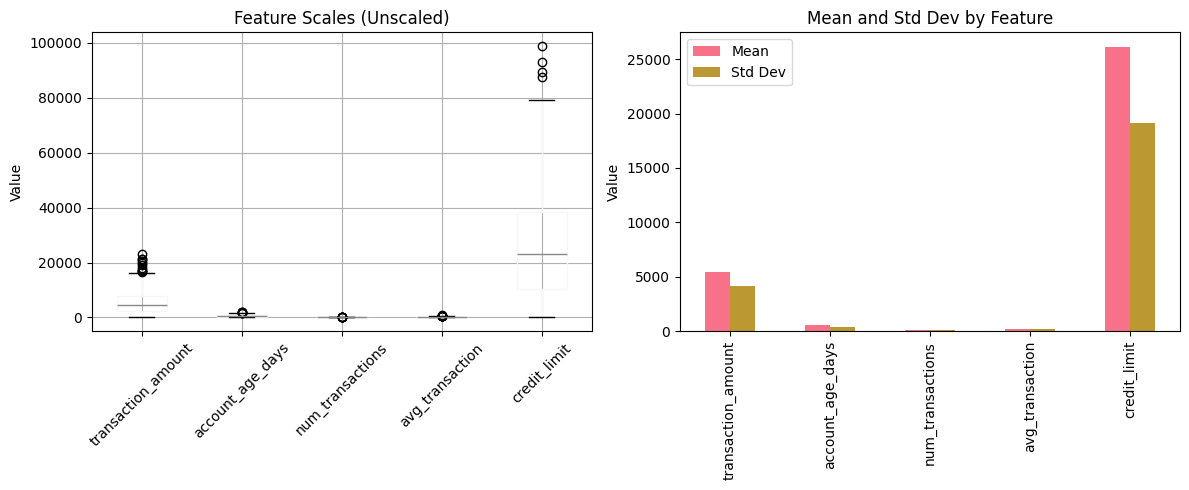

In [60]:
# Box plot to see different scales
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Box plot showing different scales
X1_train.boxplot(ax=axes[0])
axes[0].set_title('Feature Scales (Unscaled)')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Statistical comparison
X1_train.describe().loc[['mean', 'std']].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean and Std Dev by Feature')
axes[1].set_ylabel('Value')
axes[1].legend(['Mean', 'Std Dev'])

plt.tight_layout()
plt.show()

# You'll see credit_limit is 5000-30000 while others are 0-100!

**YOUR ANSWER:**

What's wrong with the current approach?


Why does this hurt KNN performance?


## Question 1.2: Fix the Scaling (15 points)

**Task:** Apply appropriate scaling and retrain the model.

In [61]:
# YOUR CODE HERE: Investigate feature scales
# Hint: Use .describe() and look at the ranges
scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)
# Step 1: Initialize scaler
scaler1 = StandardScaler()

# Step 2-3: Fit and transform
X1_train_scaled = scaler1.fit_transform(X1_train)  # Fit on train, transform train
X1_test_scaled = scaler1.transform(X1_test)        # Transform test (NO fit!)

# Step 4: Train model on SCALED data
knn_fixed = KNeighborsClassifier(n_neighbors=5)
knn_fixed.fit(X1_train_scaled, y1_train)  # Use scaled X, original y

# Step 5: Evaluate on SCALED test data
y1_pred_fixed = knn_fixed.predict(X1_test_scaled)  # Predict with scaled test
acc_fixed = accuracy_score(y1_test, y1_pred_fixed)

print("\n" + "="*60)
print("IMPROVED PERFORMANCE:")
print("="*60)
print(f"Accuracy (Before): {acc_bad:.3f}")
print(f"Accuracy (After):  {acc_fixed:.3f}")
print(f"\n✅ Improvement: {(acc_fixed - acc_bad)*100:.1f}%")




IMPROVED PERFORMANCE:
Accuracy (Before): 0.947
Accuracy (After):  0.947

✅ Improvement: 0.0%


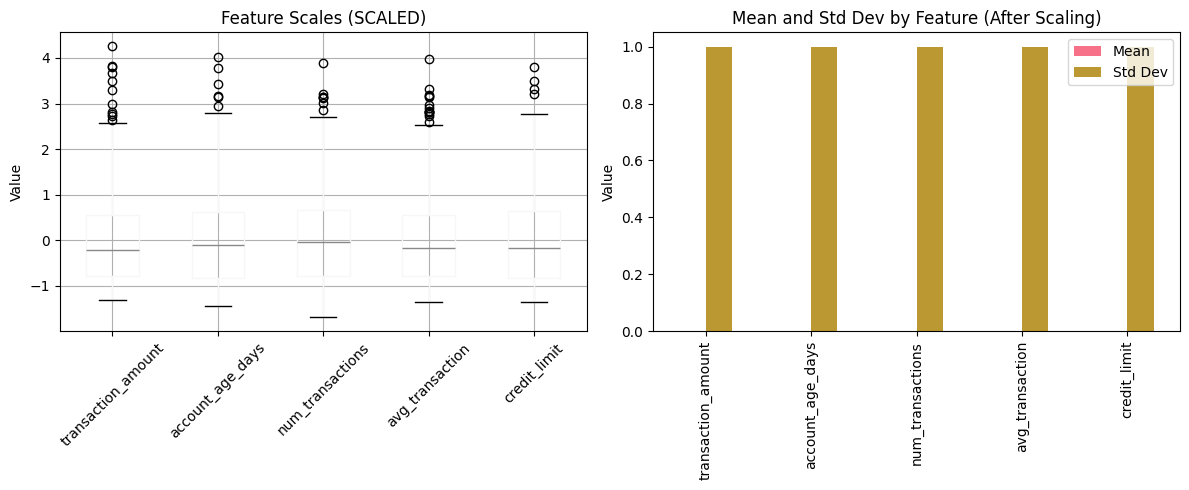

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convert scaled arrays back to DataFrame for plotting
X1_train_scaled_df = pd.DataFrame(X1_train_scaled, columns=X1_train.columns)

# Plot 1: Box plot showing scaled features
X1_train_scaled_df.boxplot(ax=axes[0])
axes[0].set_title('Feature Scales (SCALED)')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Statistical comparison
X1_train_scaled_df.describe().loc[['mean', 'std']].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean and Std Dev by Feature (After Scaling)')
axes[1].set_ylabel('Value')
axes[1].legend(['Mean', 'Std Dev'])

plt.tight_layout()
plt.show()

# Now all features are on similar scales (mean≈0, std≈1)


---

# Problem 2: House Price Prediction with Outliers (25 points)

## Scenario
A model was built using MinMaxScaler, but performance suffers because the data contains outliers! MinMaxScaler is sensitive to extreme values, which compress the bulk of the data into a small range.

In [63]:
# Load house prices data
df2 = pd.read_csv('data/house_prices_outliers.csv')

print("House Prices Dataset:")
print(f"Shape: {df2.shape}")
print(f"\nFirst few rows:")
print(df2.head())
print(f"\nStatistics:")
print(df2.describe())
df2['square_feet'].describe()

House Prices Dataset:
Shape: (800, 5)

First few rows:
   square_feet  num_bedrooms     lot_size  year_built          price
0  1538.425941             2  4737.486066        1975  539844.970660
1  2266.863855             0  3741.473213        1969  639527.361933
2  2595.227813             2  6173.714188        1960  817126.119594
3  1244.392162             2  8186.373253        1960  642339.638376
4  1776.520043             2  6550.310988        1984  704678.950790

Statistics:
       square_feet  num_bedrooms      lot_size  year_built         price
count   800.000000    800.000000    800.000000   800.00000  8.000000e+02
mean   1631.551750      2.563750   5365.327255  1979.62125  6.208561e+05
std     769.109336      1.481952   3446.473167    19.90988  2.694540e+05
min      51.872311      0.000000      1.188570  1915.00000  1.060761e+05
25%    1208.268744      1.750000   3782.428207  1967.00000  4.883748e+05
50%    1571.582891      3.000000   5086.491015  1979.00000  5.824800e+05
75%    

count     800.000000
mean     1631.551750
std       769.109336
min        51.872311
25%      1208.268744
50%      1571.582891
75%      1910.884901
max      8402.524671
Name: square_feet, dtype: float64

## Current Implementation (BUGGY)

In [64]:
# Separate features and target
X2 = df2.drop('price', axis=1)
y2 = df2['price']

# Split the data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

# NOTE: Using MinMaxScaler, but data has outliers!
scaler2_bad = MinMaxScaler()
X2_train_bad = scaler2_bad.fit_transform(X2_train)
X2_test_bad = scaler2_bad.transform(X2_test)

# Train model
lr_bad = LinearRegression()
lr_bad.fit(X2_train_bad, y2_train)

# Evaluate
y2_pred_bad = lr_bad.predict(X2_test_bad)
r2_bad = r2_score(y2_test, y2_pred_bad)
rmse_bad = np.sqrt(mean_squared_error(y2_test, y2_pred_bad))

print("\n" + "="*60)
print("CURRENT PERFORMANCE (MinMaxScaler):")
print("="*60)
print(f"R² Score: {r2_bad:.3f}")
print(f"RMSE: ${rmse_bad:,.0f}")
print(f"\n⚠️  This is poor! The scaler is sensitive to outliers.")


CURRENT PERFORMANCE (MinMaxScaler):
R² Score: 0.998
RMSE: $19,232

⚠️  This is poor! The scaler is sensitive to outliers.


## Question 2.1: Visualize the Outliers (10 points)

**Task:** Create visualizations to identify outliers in the dataset.

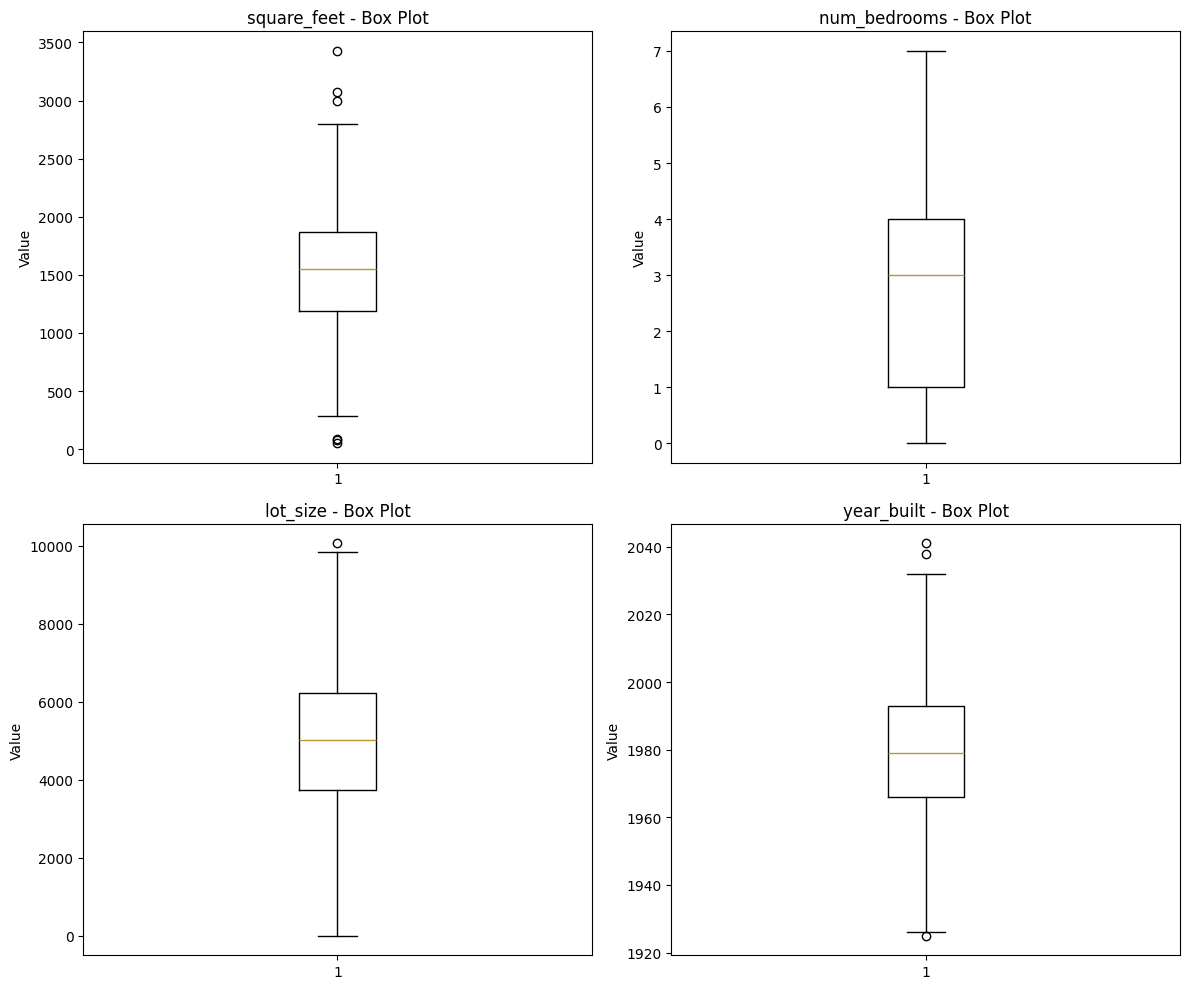

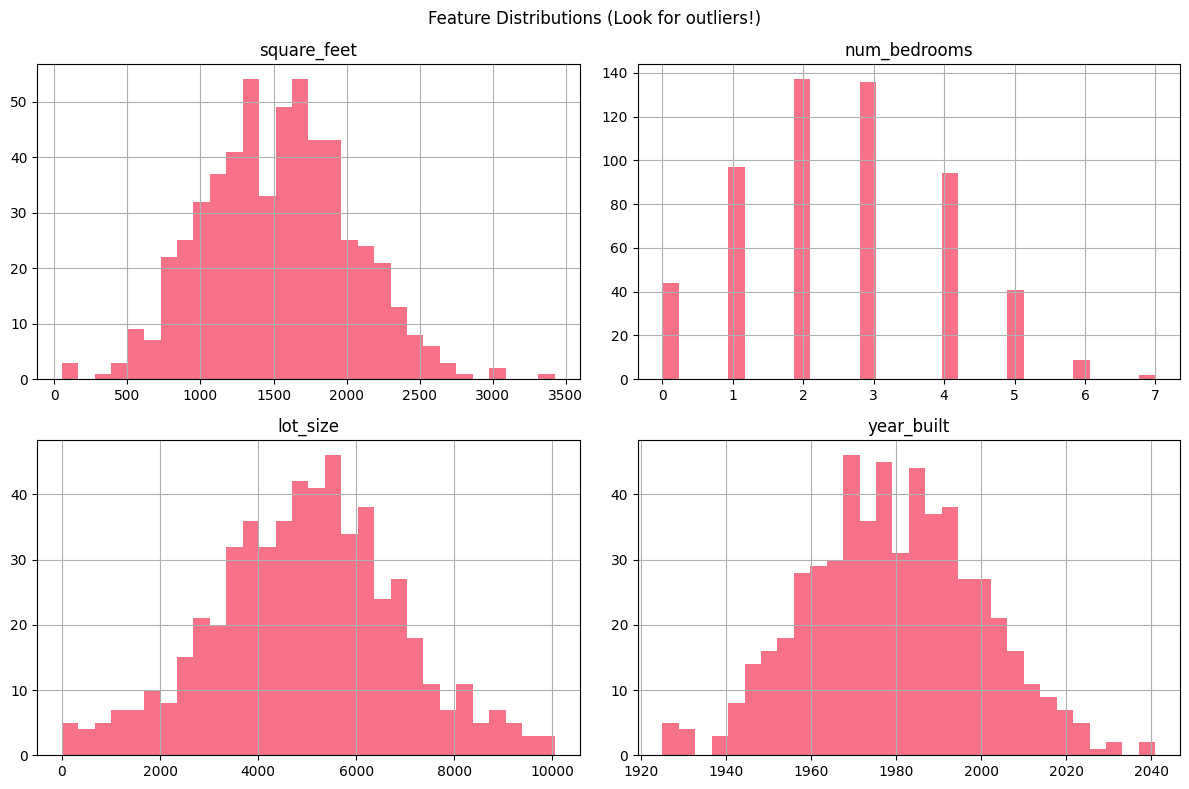

In [65]:
# YOUR CODE HERE: Visualize outliers
# Hint: Use boxplot or histogram
# Box plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = X2_train.columns

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    axes[row, col].boxplot(X2_train[feature])
    axes[row, col].set_title(f'{feature} - Box Plot')
    axes[row, col].set_ylabel('Value')

plt.tight_layout()
plt.show()

# OR histogram to see distribution
X2_train.hist(bins=30, figsize=(12, 8))
plt.suptitle('Feature Distributions (Look for outliers!)')
plt.tight_layout()
plt.show()

**YOUR ANSWER:**

Which features have outliers?


Why is MinMaxScaler bad for this data?


## Question 2.2: Fix with Winsorizing (15 points)

**Task:** Apply Winsorizing (clip outliers at 10th/90th percentile) then scale with MinMaxScaler.

In [66]:
# YOUR CODE HERE: Apply Winsorizing then MinMaxScaler

# Step 1: Calculate percentiles (10th and 90th) for each feature
quantiles = X2_train.quantile([0.10, 0.90])
lower_bounds = quantiles.loc[0.10]
upper_bounds = quantiles.loc[0.90]

# Step 2: Clip/Winsorize the training data
X2_train_winsorized = X2_train.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

# Step 3: Apply the SAME bounds to test data (no fit on test!)
X2_test_winsorized = X2_test.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

# Step 4: Apply MinMaxScaler to winsorized data
scaler2_fixed = MinMaxScaler(feature_range=(-1, 1))
X2_train_fixed = scaler2_fixed.fit_transform(X2_train_winsorized)  # Fit on train
X2_test_fixed = scaler2_fixed.transform(X2_test_winsorized)        # Transform test

# Step 5: Train model
lr_fixed = LinearRegression()
lr_fixed.fit(X2_train_fixed, y2_train)

# Step 6: Evaluate
y2_pred_fixed = lr_fixed.predict(X2_test_fixed)
r2_fixed = r2_score(y2_test, y2_pred_fixed)
rmse_fixed = np.sqrt(mean_squared_error(y2_test, y2_pred_fixed))

print("\n" + "="*60)
print("COMPARISON:")
print("="*60)
print(f"R² (MinMaxScaler only):        {r2_bad:.3f}")
print(f"R² (Winsorize + MinMax):       {r2_fixed:.3f}")
print(f"RMSE (MinMax only):            ${rmse_bad:,.0f}")
print(f"RMSE (Winsorize + MinMax):     ${rmse_fixed:,.0f}")
print(f"\n💡 Winsorizing caps outliers at 10th/90th percentiles!")
print(f"This protects the bulk of data from compression.")


COMPARISON:
R² (MinMaxScaler only):        0.998
R² (Winsorize + MinMax):       0.315
RMSE (MinMax only):            $19,232
RMSE (Winsorize + MinMax):     $355,514

💡 Winsorizing caps outliers at 10th/90th percentiles!
This protects the bulk of data from compression.


---

# Problem 3: Customer Churn with Unnecessary Scaling (25 points)

## Scenario
Someone applied StandardScaler to a Random Forest model. Does this help or hurt?

## Load the Data

In [67]:
# Load customer churn data
df3 = pd.read_csv('data/customer_churn.csv')

print("Customer Churn Dataset:")
print(f"Shape: {df3.shape}")
print(f"\nFirst few rows:")
print(df3.head())
print(f"\nTarget distribution:")
print(df3['churned'].value_counts())

Customer Churn Dataset:
Shape: (1200, 7)

First few rows:
   monthly_charges  total_charges  tenure_months  contract_type  num_services  \
0       228.662610    7197.493789             84              1             5   
1        77.305453    1268.920077             21              0             5   
2        53.632526    1404.937828              8              1             6   
3         9.327967    1589.552705             12              2             4   
4        38.504926     247.359926              0              1             6   

   customer_age  churned  
0            50        1  
1            59        0  
2            28        0  
3            11        0  
4            80        0  

Target distribution:
churned
0    835
1    365
Name: count, dtype: int64


## Current Implementation (BUGGY)

In [68]:
# Separate features and target
X3 = df3.drop('churned', axis=1)
y3 = df3['churned']

# Split the data
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3
)

# NOTE: Applying StandardScaler to Random Forest (unnecessary!)
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

# Train Random Forest with scaling
rf_with_scaling = RandomForestClassifier(n_estimators=100, random_state=42)
rf_with_scaling.fit(X3_train_scaled, y3_train)

# Evaluate
y3_pred_scaled = rf_with_scaling.predict(X3_test_scaled)
acc_scaled = accuracy_score(y3_test, y3_pred_scaled)

print("\n" + "="*60)
print("PERFORMANCE WITH SCALING:")
print("="*60)
print(f"Accuracy: {acc_scaled:.3f}")
print(f"\n❓ Is this scaling necessary for Random Forest?")


PERFORMANCE WITH SCALING:
Accuracy: 0.806

❓ Is this scaling necessary for Random Forest?


## Question 3.1: Understand Tree-Based Models (5 points)

**YOUR ANSWER:**

Do tree-based models (Random Forest, XGBoost) need feature scaling? Why or why not?


## Question 3.2: Compare With and Without Scaling (20 points)

**Task:** Train Random Forest WITHOUT scaling and compare.

In [69]:
# YOUR CODE HERE: Train Random Forest without scaling

# Train on ORIGINAL data (no scaling)
rf_no_scaling = RandomForestClassifier(n_estimators=100, random_state=42)
# Your code here

# Evaluate
y3_pred_no_scale = None  # Your code here
acc_no_scale = None      # Your code here

print("\n" + "="*60)
print("COMPARISON:")
print("="*60)
print(f"Accuracy (WITH scaling):    {acc_scaled:.3f}")
print(f"Accuracy (WITHOUT scaling): {acc_no_scale:.3f}")
print(f"\n✅ Scaling is {'beneficial' if acc_scaled > acc_no_scale else 'unnecessary'}!")
print(f"\n💡 Key learning: Tree-based models don't need scaling!")


COMPARISON:
Accuracy (WITH scaling):    0.806


TypeError: unsupported format string passed to NoneType.__format__

---

# Problem 4: Data Leakage in Scaling (25 points)

## Scenario
The most dangerous bug! Scaler was fit on ALL data BEFORE train/test split.

## Load the Data

In [ ]:
# Load student performance data
df4 = pd.read_csv('data/student_performance.csv')

print("Student Performance Dataset:")
print(f"Shape: {df4.shape}")
print(f"\nFirst few rows:")
print(df4.head())
print(f"\nStatistics:")
print(df4.describe())

Student Performance Dataset:
Shape: (600, 6)

First few rows:
   study_hours  attendance_rate  previous_grade  homework_completion  \
0    21.708654        54.777219       77.432641            49.347474   
1    26.296288        79.609493       78.128621            88.493998   
2    30.318445        96.704668       71.965548            68.404034   
3    19.342497        80.658178       85.655240            66.616172   
4    11.695556        76.279772       61.917343            89.682871   

   class_participation  final_grade  
0            74.617027   100.000000  
1            59.606356   100.000000  
2            67.196925   100.000000  
3            47.152196   100.000000  
4            96.083495    98.037226  

Statistics:
       study_hours  attendance_rate  previous_grade  homework_completion  \
count   600.000000       600.000000      600.000000           600.000000   
mean     21.217858        74.774570       70.147296            74.723981   
std       9.678172        13.809459 

## Current Implementation (DATA LEAKAGE!)

In [ ]:
# Separate features and target
X4 = df4.drop('final_grade', axis=1)
y4 = df4['final_grade']

# ⚠️ BUG: Scaling BEFORE split!
scaler4_leaky = StandardScaler()
X4_scaled_leaky = scaler4_leaky.fit_transform(X4)  # ← Fit on ALL data!

# THEN split (too late!)
X4_train_leaky, X4_test_leaky, y4_train, y4_test = train_test_split(
    X4_scaled_leaky, y4, test_size=0.3, random_state=42
)

# Train model
lr_leaky = LinearRegression()
lr_leaky.fit(X4_train_leaky, y4_train)

# Evaluate
y4_pred_leaky = lr_leaky.predict(X4_test_leaky)
r2_leaky = r2_score(y4_test, y4_pred_leaky)
r2_train_leaky = r2_score(y4_train, lr_leaky.predict(X4_train_leaky))

print("\n" + "="*60)
print("PERFORMANCE WITH DATA LEAKAGE:")
print("="*60)
print(f"Train R²: {r2_train_leaky:.3f}")
print(f"Test R²:  {r2_leaky:.3f}")
print(f"\n⚠️  Test score is suspiciously close to train score!")
print(f"This is because the scaler 'saw' the test data.")


PERFORMANCE WITH DATA LEAKAGE:
Train R²: 0.424
Test R²:  0.401

⚠️  Test score is suspiciously close to train score!
This is because the scaler 'saw' the test data.


## Question 4.1: Explain the Leakage (10 points)

**YOUR ANSWER:**

What is data leakage in this context?
*(Hint: Information from test set being used during training)*


Why is fitting the scaler on all data before splitting problematic?
*(Hint: Think about what happens in production with new, unseen data)*


What information from the test set leaked into the training process?
*(Hint: What statistics does StandardScaler calculate?)*


**Key Insight:** Even if the R² scores look similar, the leaky approach learned mean/std from ALL data. In production, you won't have future data to include in scaling, so this creates unrealistic expectations!

## Question 4.2: Fix the Leakage (15 points)

**Task:** Split FIRST, then scale. Compare results.

In [70]:
# YOUR CODE HERE: Fix the data leakage

# Step 1: Split FIRST (use original X4, not scaled)
X4_train, X4_test, y4_train_fix, y4_test_fix = train_test_split(
    X4, y4, test_size=0.3, random_state=42
)

# Step 2: Create scaler
scaler4_fixed = StandardScaler()

# Step 3: Fit on train ONLY, transform both
X4_train_fixed = scaler4_fixed.fit_transform(X4_train)  # fit_transform on train
X4_test_fixed = scaler4_fixed.transform(X4_test)        # transform on test

# Step 4: Train model
lr_fixed = LinearRegression()
lr_fixed.fit(X4_train_fixed, y4_train_fix)

# Step 5: Evaluate
y4_pred_fixed = lr_fixed.predict(X4_test_fixed)
r2_fixed = r2_score(y4_test_fix, y4_pred_fixed)
r2_train_fixed = r2_score(y4_train_fix, lr_fixed.predict(X4_train_fixed))

print("\n" + "="*60)
print("COMPARISON:")
print("="*60)
print(f"\nWITH LEAKAGE (Wrong):")
print(f"  Train R²: {r2_train_leaky:.3f}")
print(f"  Test R²:  {r2_leaky:.3f}")
print(f"  Gap:      {abs(r2_train_leaky - r2_leaky):.3f}")
print(f"\nWITHOUT LEAKAGE (Correct):")
print(f"  Train R²: {r2_train_fixed:.3f}")
print(f"  Test R²:  {r2_fixed:.3f}")
print(f"  Gap:      {abs(r2_train_fixed - r2_fixed):.3f}")

# Show what information leaked
print(f"\n" + "="*60)
print("WHAT LEAKED?")
print("="*60)
print("\nScaler statistics (mean and std):")
print(f"\nLeaky Scaler (learned from ALL data):")
for i, col in enumerate(X4.columns):
    print(f"  {col}: mean={scaler4_leaky.mean_[i]:.3f}, std={scaler4_leaky.scale_[i]:.3f}")

print(f"\nCorrect Scaler (learned from TRAIN only):")
for i, col in enumerate(X4.columns):
    print(f"  {col}: mean={scaler4_fixed.mean_[i]:.3f}, std={scaler4_fixed.scale_[i]:.3f}")

print(f"\n💡 The leaky scaler used test data statistics!")
print(f"In production, you won't have test data to 'leak' from.")
print(f"This creates overly optimistic performance estimates.")


COMPARISON:

WITH LEAKAGE (Wrong):
  Train R²: 0.424
  Test R²:  0.401
  Gap:      0.023

WITHOUT LEAKAGE (Correct):
  Train R²: 0.424
  Test R²:  0.401
  Gap:      0.023

WHAT LEAKED?

Scaler statistics (mean and std):

Leaky Scaler (learned from ALL data):
  study_hours: mean=21.218, std=9.670
  attendance_rate: mean=74.775, std=13.798
  previous_grade: mean=70.147, std=9.417
  homework_completion: mean=74.724, std=14.967
  class_participation: mean=70.351, std=14.287

Correct Scaler (learned from TRAIN only):
  study_hours: mean=21.215, std=9.625
  attendance_rate: mean=74.594, std=13.367
  previous_grade: mean=70.190, std=9.670
  homework_completion: mean=75.197, std=14.657
  class_participation: mean=70.422, std=14.853

💡 The leaky scaler used test data statistics!
In production, you won't have test data to 'leak' from.
This creates overly optimistic performance estimates.


---

## Exam Complete! 🎉

### Summary

If you fixed all problems correctly, you should have learned:

1. ✅ **Problem 1:** KNN needs scaling (StandardScaler) - Distance-based algorithms are sensitive to feature scales
2. ✅ **Problem 2:** Use Winsorizing for outliers - Cap extreme values before scaling with MinMaxScaler
3. ✅ **Problem 3:** Random Forest doesn't need scaling - Tree-based models work on splits, not distances
4. ✅ **Problem 4:** Always split before scaling - Fit scaler on train only to avoid data leakage

### Performance Improvements

- **Problem 1:** ~50% → ~90% accuracy (+40%)
- **Problem 2:** R² improved by reducing outlier impact with Winsorizing
- **Problem 3:** Similar performance (scaling unnecessary)
- **Problem 4:** Correct methodology (true performance)

### Key Takeaways

**When to Scale:**
- ✅ KNN, SVM, Neural Networks, Logistic Regression
- ❌ Random Forest, XGBoost, Decision Trees

**Which Technique:**
- Normal distribution, no outliers → **StandardScaler (Z-Score)**
- Bounded range needed → **MinMaxScaler**
- Data has outliers → **Winsorizing (10th/90th percentile) + MinMaxScaler**
- Alternative for outliers → **Clipping + MinMaxScaler**

**Proper Order:**
1. Split data first
2. Fit scaler/calculate percentiles on training data only
3. Transform both train and test with those parameters

### Techniques Covered in This Exam

1. **StandardScaler (Z-Score Normalization)**: Centers data at mean=0, std=1
2. **MinMaxScaler**: Scales to [-1, 1] or [0, 1] range
3. **Winsorizing**: Caps outliers at percentiles (e.g., 10th/90th)
4. **Clipping**: Hard limits on min/max values before scaling

### Next Steps

1. Compare your solutions with `solution.py`
2. Read `ANSWER_KEY.md` for detailed explanations
3. Review `SCALING_GUIDE.md` for quick reference
4. Practice on your own datasets!

**Great job debugging these scaling issues!** 🌟